In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("bmi.csv")
df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [2]:
df.isnull()

,Gender,Height,Weight,Index
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
495,False,False,False,False
496,False,False,False,False
497,False,False,False,False
498,False,False,False,False


In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

X = df[['Gender', 'Height', 'Weight']]
y = df['Index']
df_std = df.copy()
scaler_std = StandardScaler()
df_std[['Height', 'Weight']] = scaler_std.fit_transform(df_std[['Height', 'Weight']])
print("\nStandard Scaled Data:")
print(df_std.head())


Standard Scaled Data:
   Gender    Height    Weight  Index
0    Male  0.247939 -0.309117      4
1    Male  1.164872 -0.587322      2
2  Female  0.920357  0.123647      4
3  Female  1.531645 -0.061823      3
4    Male -1.280283 -1.391027      3


In [5]:
df_minmax = df.copy()
scaler_minmax = MinMaxScaler()
df_minmax[['Height', 'Weight']] = scaler_minmax.fit_transform(df_minmax[['Height', 'Weight']])

print("\nMin-Max Scaled Data:")
print(df_minmax.head())



Min-Max Scaled Data:
   Gender    Height    Weight  Index
0    Male  0.576271  0.418182      4
1    Male  0.830508  0.336364      2
2  Female  0.762712  0.545455      4
3  Female  0.932203  0.490909      3
4    Male  0.152542  0.100000      3


In [6]:
df_maxabs = df.copy()
scaler_maxabs = MaxAbsScaler()
df_maxabs[['Height', 'Weight']] = scaler_maxabs.fit_transform(df_maxabs[['Height', 'Weight']])
print("\nMaxAbs Scaled Data:")
print(df_maxabs.head())


MaxAbs Scaled Data:
   Gender    Height   Weight  Index
0    Male  0.874372  0.60000      4
1    Male  0.949749  0.54375      2
2  Female  0.929648  0.68750      4
3  Female  0.979899  0.65000      3
4    Male  0.748744  0.38125      3


In [7]:
df_robust = df.copy()
scaler_robust = RobustScaler()
df_robust[['Height', 'Weight']] = scaler_robust.fit_transform(df_robust[['Height', 'Weight']])

print("\nRobust Scaled Data:")
print(df_robust.head())


Robust Scaled Data:
   Gender    Height    Weight  Index
0    Male  0.125000 -0.178571      4
1    Male  0.660714 -0.339286      2
2  Female  0.517857  0.071429      4
3  Female  0.875000 -0.035714      3
4    Male -0.767857 -0.803571      3


In [8]:
df_std.to_csv("BMI_StandardScaled.csv", index=False)
df_minmax.to_csv("BMI_MinMaxScaled.csv", index=False)
df_maxabs.to_csv("BMI_MaxAbsScaled.csv", index=False)
df_robust.to_csv("BMI_RobustScaled.csv", index=False)


--- 1. FILTER METHOD (Correlation Matrix) ---


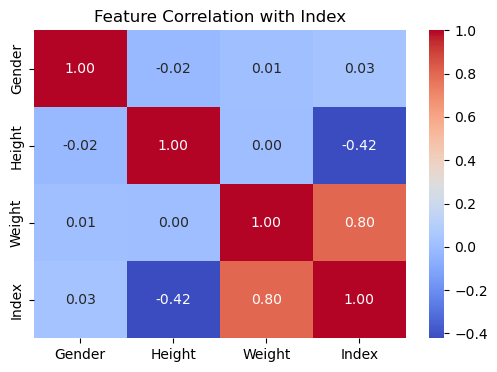


--- 2. EMBEDDED METHOD (Feature Importance) ---
Feature Importance Scores:
Weight    0.638867
Height    0.349939
Gender    0.011193
dtype: float64


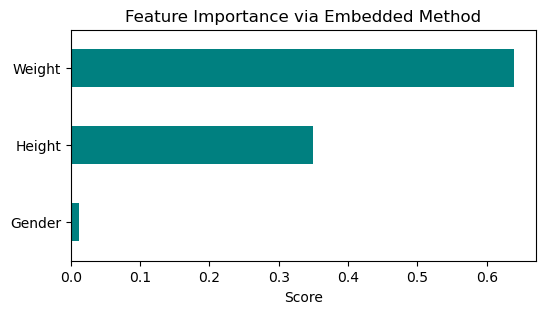

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df_std['Gender'] = df_std['Gender'].map({'Male': 1, 'Female': 0})

X_selection = df_std[['Gender', 'Height', 'Weight']]
y_selection = df_std['Index']

print("--- 1. FILTER METHOD (Correlation Matrix) ---")
plt.figure(figsize=(6, 4))
sns.heatmap(df_std.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Index")
plt.show()


print("\n--- 2. EMBEDDED METHOD (Feature Importance) ---")
model = RandomForestClassifier(random_state=42)
model.fit(X_selection, y_selection)

importances = pd.Series(model.feature_importances_, index=X_selection.columns)
importances = importances.sort_values(ascending=False)

print("Feature Importance Scores:")
print(importances)


plt.figure(figsize=(6, 3))
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance via Embedded Method")
plt.xlabel("Score")
plt.gca().invert_yaxis()
plt.show()